In [1]:
import torch
import torchvision
import torch.nn as nn

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Автокодировщик

основная модель MNIST-MNIST

Модель шумоподавления:
    
    - вход : изображения 28х28 с гаусовым шумом (параметр уровня зашумления noise)
    - выход : изображение 28х28 идеальное
    
    - потери : MSE
    - метрика : PSNR (https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio)

## задание 1
    1.1 реализовать метрику PSNR
    1.2 проверить на примерах ее качество : сравнить изображение с разной степенью зашумления с идеальным имсходным изображением


In [2]:
# 1.1
from torch import Tensor, tensor

def psnr_compute(target: Tensor, y: Tensor, num_obs: Tensor, data_range: Tensor, base: float = 10.0,  image_size=28) -> Tensor:
    """peak signal-to-noise ratio.

    Args:
        sum_squared_error: суммарная квадратичная ощибка наблюдений
        num_obs: число объектов
        data_range: диапазон сигнала.
        base: основание логарифма
        reduction: метод ["elementwise_mean", "sum", "none", None]

            - ``'elementwise_mean'``: среднее(default)
            - ``'sum'``: сумма
            - ``'none'`` or ``None``: без объединения

    """
    sum_squared_error = torch.sum((target - y)**2).cpu()
    mse = sum_squared_error / (num_obs * image_size * image_size)

    psnr_base_e = 2 * torch.log(data_range) - torch.log(mse)
    psnr_vals = psnr_base_e * (10 / torch.log(tensor(base)))
    return torch.mean(psnr_vals)

In [4]:
from torchvision import datasets, transforms

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.5MB/s]


0.10            22.31           Norm
0.30            13.31           Bad
0.50            9.44            Bad
0.70            7.69            Bad
1.00            5.89            Bad


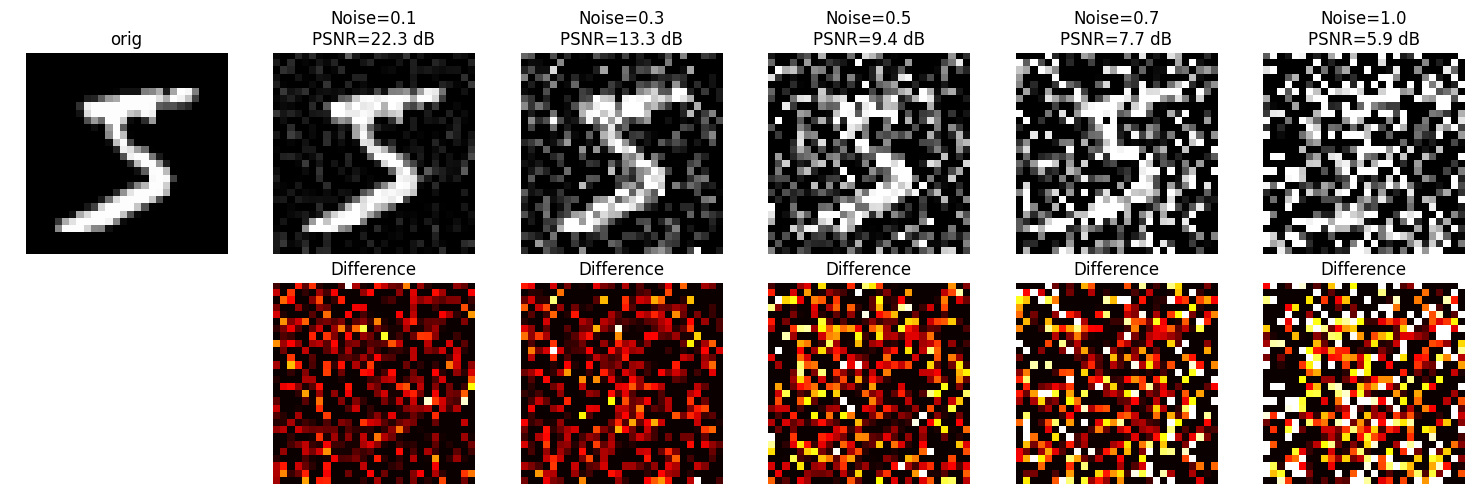

In [5]:
# 1.2
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

original_image = mnist[0][0]

noise_levels = [0.1, 0.3, 0.5, 0.7, 1.0]

fig, axes = plt.subplots(2, len(noise_levels) + 1, figsize=(15, 5))

axes[0, 0].imshow(original_image.squeeze(), cmap='gray')
axes[0, 0].set_title('orig')
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for idx, noise_level in enumerate(noise_levels):
    noisy_image = original_image + noise_level * torch.randn_like(original_image)
    noisy_image = torch.clamp(noisy_image, 0, 1)

    psnr_value = psnr_compute(
        target=original_image.unsqueeze(0),
        y=noisy_image.unsqueeze(0),
        num_obs=tensor(1.0),
        data_range=tensor(1.0),
        image_size=28
    )

    if psnr_value > 40:
        quality = "Excellent"
    elif psnr_value > 30:
        quality = "Good"
    elif psnr_value > 20:
        quality = "Norm"
    else:
        quality = "Bad"

    print(f"{noise_level:<15.2f} {psnr_value.item():<15.2f} {quality}")

    axes[0, idx + 1].imshow(noisy_image.squeeze(), cmap='gray')
    axes[0, idx + 1].set_title(f'Noise={noise_level}\nPSNR={psnr_value.item():.1f} dB')
    axes[0, idx + 1].axis('off')

    diff = torch.abs(original_image - noisy_image)
    axes[1, idx + 1].imshow(diff.squeeze(), cmap='hot')
    axes[1, idx + 1].set_title('Difference')
    axes[1, idx + 1].axis('off')

plt.tight_layout()
plt.show()

## задание 2
    2.1 собрать модель автоэнкодера с изменяемой шириной и глубиной энкодера и декодера
    2.2 проверить сборку на тестовом примере: тензор на входе соответсвует целевому размеру входного изображения, оцениваем тензор на выходе

In [6]:
import torch
import torch.nn as nn
import numpy as np

def blocc(h1, h2, hiden_size, kernel):
    return nn.Sequential(
        nn.Conv2d(h1, hiden_size, kernel, padding=1),
        nn.BatchNorm2d(hiden_size),
        nn.ReLU(),
        nn.Conv2d(hiden_size, h2, kernel, padding=1),
        nn.BatchNorm2d(h2),
        nn.ReLU()
    )

class Encoder(nn.Module):
    def __init__(self, hiden_size, im_size, depth=3):
        super(Encoder, self).__init__()
        self.im_size = im_size
        self.hiden_size = hiden_size
        self.depth = depth

        self.conv_blocks = nn.ModuleList()
        self.pool_blocks = nn.ModuleList()

        in_channels = self.im_size[0]
        for i in range(depth):
            out_channels = hiden_size * (2 ** (i + 1))
            self.conv_blocks.append(blocc(in_channels, out_channels, out_channels // 2, 3))
            self.pool_blocks.append(nn.MaxPool2d(2, 2))
            in_channels = out_channels

        final_size = (im_size[1] // (2 ** depth)) * (im_size[2] // (2 ** depth))
        self.latent = nn.Linear(final_size * hiden_size * (2 ** depth), hiden_size * (2 ** depth))

    def forward(self, input_):
        x = input_
        for conv, pool in zip(self.conv_blocks, self.pool_blocks):
            x = conv(x)
            x = pool(x)

        x = x.reshape(input_.shape[0], -1)
        x = self.latent(x)
        return x

class Decoder(nn.Module):
    def __init__(self, hiden_size, im_size, depth=3):
        super(Decoder, self).__init__()
        self.im_size = im_size
        self.hiden_size = hiden_size
        self.depth = depth

        final_size = (im_size[1] // (2 ** depth)) * (im_size[2] // (2 ** depth))
        self.latent = nn.Linear(hiden_size * (2 ** depth), final_size * hiden_size * (2 ** depth))

        self.conv_blocks = nn.ModuleList()
        self.upsample_blocks = nn.ModuleList()

        for i in range(depth - 1, -1, -1):
            in_channels = hiden_size * (2 ** (i + 1))
            out_channels = hiden_size * (2 ** i) if i > 0 else hiden_size

            self.conv_blocks.append(blocc(in_channels, out_channels, in_channels, 3))
            self.upsample_blocks.append(
                nn.ConvTranspose2d(out_channels, out_channels, kernel_size=2, stride=2, padding=0)
            )

        self.final_conv = nn.Conv2d(hiden_size, self.im_size[0], 1, padding=0)
        self.out = nn.Sigmoid()

    def forward(self, input_):
        x = self.latent(input_)

        final_size = self.im_size[1] // (2 ** self.depth)
        x = x.reshape(input_.shape[0], self.hiden_size * (2 ** self.depth), final_size, final_size)

        for conv, upsample in zip(self.conv_blocks, self.upsample_blocks):
            x = conv(x)
            x = upsample(x)

        x = self.final_conv(x)

        if x.shape[2] != self.im_size[1] or x.shape[3] != self.im_size[2]:
            x = nn.functional.interpolate(x, size=(self.im_size[1], self.im_size[2]), mode='bilinear', align_corners=False)

        return self.out(x)

class Autoencoder_Base(nn.Module):
    def __init__(self, hiden_size, im_size, depth=3):
        super(Autoencoder_Base, self).__init__()
        self.encoder = Encoder(hiden_size, im_size, depth)
        self.decoder = Decoder(hiden_size, im_size, depth)
        self.im_size = im_size

    def forward(self, input_):
        return self.decoder(self.encoder(input_))

In [7]:
configs = [
    (8, 2),
    (8, 3),
    (8, 4),
    (16, 3),
]

X = torch.randn(2, 1, 28, 28)

for hiden_size, depth in configs:
    AE = Autoencoder_Base(hiden_size, [1, 28, 28], depth=depth)

    with torch.no_grad():
        out = AE(X)

    params = sum(p.numel() for p in AE.parameters())

    assert X.shape == out.shape, f"err: input {X.shape} != output {out.shape}"
    print(out.shape)

AE = Autoencoder_Base(8, [1, 28, 28], depth=3)
test_batch_sizes = [1, 4, 8, 16]
for bs in test_batch_sizes:
    X_test = torch.randn(bs, 1, 28, 28)
    out_test = AE(X_test)
    assert X_test.shape == out_test.shape, f"err for batch size {bs}"

torch.Size([2, 1, 28, 28])
torch.Size([2, 1, 28, 28])
torch.Size([2, 1, 28, 28])
torch.Size([2, 1, 28, 28])


## задание 3
    3.1 Загрузить данные MNIST (рукописные цифры)
    3.2 Создать датасет с зашумлением данных по заданной форме: гаусовый шум, шум "соль/перец", регуляррные полосы
    3.3 проверить на примерах ее качество формировния входа (оценить PSNR - сравнить изображение с разной степенью зашумления с идеальным имсходным изображением)

Читаем MNIST

In [8]:
ds = torchvision.datasets.MNIST(root='./', train=True, download=True)
ds_test = torchvision.datasets.MNIST(root='./', train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.64MB/s]


In [42]:
class NoiseDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, noise=0.1, noise_type='gaussian'):
        self._data = dataset
        self._length = len(dataset)
        self.size = [1, 28, 28]
        self.noise = noise
        self.noise_type = noise_type

    def __len__(self):
        return len(self._data)

    def add_gaussian_noise(self, im):
        noisy = np.array(im, dtype=np.float32) + np.random.randn(self.size[1], self.size[2]) * self.noise * 255
        return np.clip(noisy, 0., 255.).astype(np.uint8)

    def add_salt_pepper_noise(self, im):
        noisy = np.array(im, dtype=np.float32).copy()

        salt = np.random.rand(self.size[1], self.size[2]) < self.noise / 2
        noisy[salt] = 255

        pepper = np.random.rand(self.size[1], self.size[2]) < self.noise / 2
        noisy[pepper] = 0

        return noisy.astype(np.uint8)

    def add_stripe_noise(self, im):
        noisy = np.array(im, dtype=np.float32).copy()

        stripe_width = max(1, int(self.size[1] * self.noise / 10))
        num_stripes = int(self.size[1] * self.noise)

        for _ in range(num_stripes):
            start = np.random.randint(0, self.size[1] - stripe_width)
            if np.random.rand() > 0.5:
                noisy[start:start+stripe_width, :] = np.random.randint(0, 256)
            else:
                noisy[:, start:start+stripe_width] = np.random.randint(0, 256)

        return np.clip(noisy, 0., 255.).astype(np.uint8)

    def encode_image(self, im):
        if self.noise_type == 'gaussian':
            return self.add_gaussian_noise(im)
        elif self.noise_type == 'salt_pepper':
            return self.add_salt_pepper_noise(im)
        elif self.noise_type == 'stripe':
            return self.add_stripe_noise(im)
        else:
            raise ValueError(f"unk: {self.noise_type}")

    def __getitem__(self, index):
        im, _ = self._data[index]
        noisy = self.encode_image(im)
        clean = np.array(im, dtype=np.float32)

        return (torch.from_numpy(noisy.astype(np.float32)[None] / 255.),
                torch.from_numpy(clean[None] / 255.))

In [10]:
train_dataset_gauss = NoiseDataset(ds, noise=0.2, noise_type='gaussian')
train_dataset_sp = NoiseDataset(ds, noise=0.2, noise_type='salt_pepper')
train_dataset_stripe = NoiseDataset(ds, noise=0.2, noise_type='stripe')

valid_dataset_gauss = NoiseDataset(ds_test, noise=0.2, noise_type='gaussian')
valid_dataset_sp = NoiseDataset(ds_test, noise=0.2, noise_type='salt_pepper')
valid_dataset_stripe = NoiseDataset(ds_test, noise=0.2, noise_type='stripe')


train_loader_gauss = torch.utils.data.DataLoader(
    train_dataset_gauss, batch_size=128, shuffle=True, num_workers=2, pin_memory=True
)
valid_loader_gauss = torch.utils.data.DataLoader(
    valid_dataset_gauss, batch_size=128, shuffle=False, num_workers=2, pin_memory=True
)

train_loader_sp = torch.utils.data.DataLoader(
    train_dataset_sp, batch_size=128, shuffle=True, num_workers=2, pin_memory=True
)
valid_loader_sp = torch.utils.data.DataLoader(
    valid_dataset_sp, batch_size=128, shuffle=False, num_workers=2, pin_memory=True
)

train_loader_stripe = torch.utils.data.DataLoader(
    train_dataset_stripe, batch_size=128, shuffle=True, num_workers=2, pin_memory=True
)
valid_loader_stripe = torch.utils.data.DataLoader(
    valid_dataset_stripe, batch_size=128, shuffle=False, num_workers=2, pin_memory=True
)

In [11]:
def visualize_noise_types():
    noise_configs = [
        ('gaussian', 0.1),
        ('gaussian', 0.3),
        ('salt_pepper', 0.1),
        ('salt_pepper', 0.3),
        ('stripe', 0.1),
        ('stripe', 0.3),
    ]

    num_samples = 4
    num_rows = len(noise_configs) + 1

    fig, axes = plt.subplots(num_rows, num_samples, figsize=(12, 3 * num_rows))

    print(f"{'Noise Type':<15} {'Level':<10} {'PSNR (dB)':<12} {'Quality'}")

    for i in range(num_samples):
        original_im, _ = ds[i]
        axes[0, i].imshow(np.array(original_im))
        axes[0, i].set_title(f'Original #{i}')
        axes[0, i].axis('off')

    for row, (noise_type, noise_level) in enumerate(noise_configs, start=1):
        dataset = NoiseDataset(ds, noise=noise_level, noise_type=noise_type)

        psnr_values = []
        for i in range(num_samples):
            im_noisy, im_clean = dataset[i]

            psnr_val = psnr_compute(
                target=im_clean.unsqueeze(0),
                y=im_noisy.unsqueeze(0),
                num_obs=torch.tensor(1.0),
                data_range=torch.tensor(1.0),
                image_size=28
            )
            psnr_values.append(psnr_val.item())

            axes[row, i].imshow(im_noisy.squeeze())
            axes[row, i].set_title(f'{noise_type}\nnoise={noise_level:.1f}\nPSNR={psnr_val.item():.1f}dB')
            axes[row, i].axis('off')

        avg_psnr = np.mean(psnr_values)

        if avg_psnr > 30:
            quality = "Good"
        elif avg_psnr > 20:
            quality = "Norm"
        else:
            quality = "Bad"

        print(f"{noise_type:<15} {noise_level:<10.1f} {avg_psnr:<12.2f} {quality}")

    plt.tight_layout()
    plt.show()

Noise Type      Level      PSNR (dB)    Quality
gaussian        0.1        22.75        Norm
gaussian        0.3        13.18        Bad
salt_pepper     0.1        13.43        Bad
salt_pepper     0.3        9.04         Bad
stripe          0.1        19.85        Bad
stripe          0.3        10.77        Bad


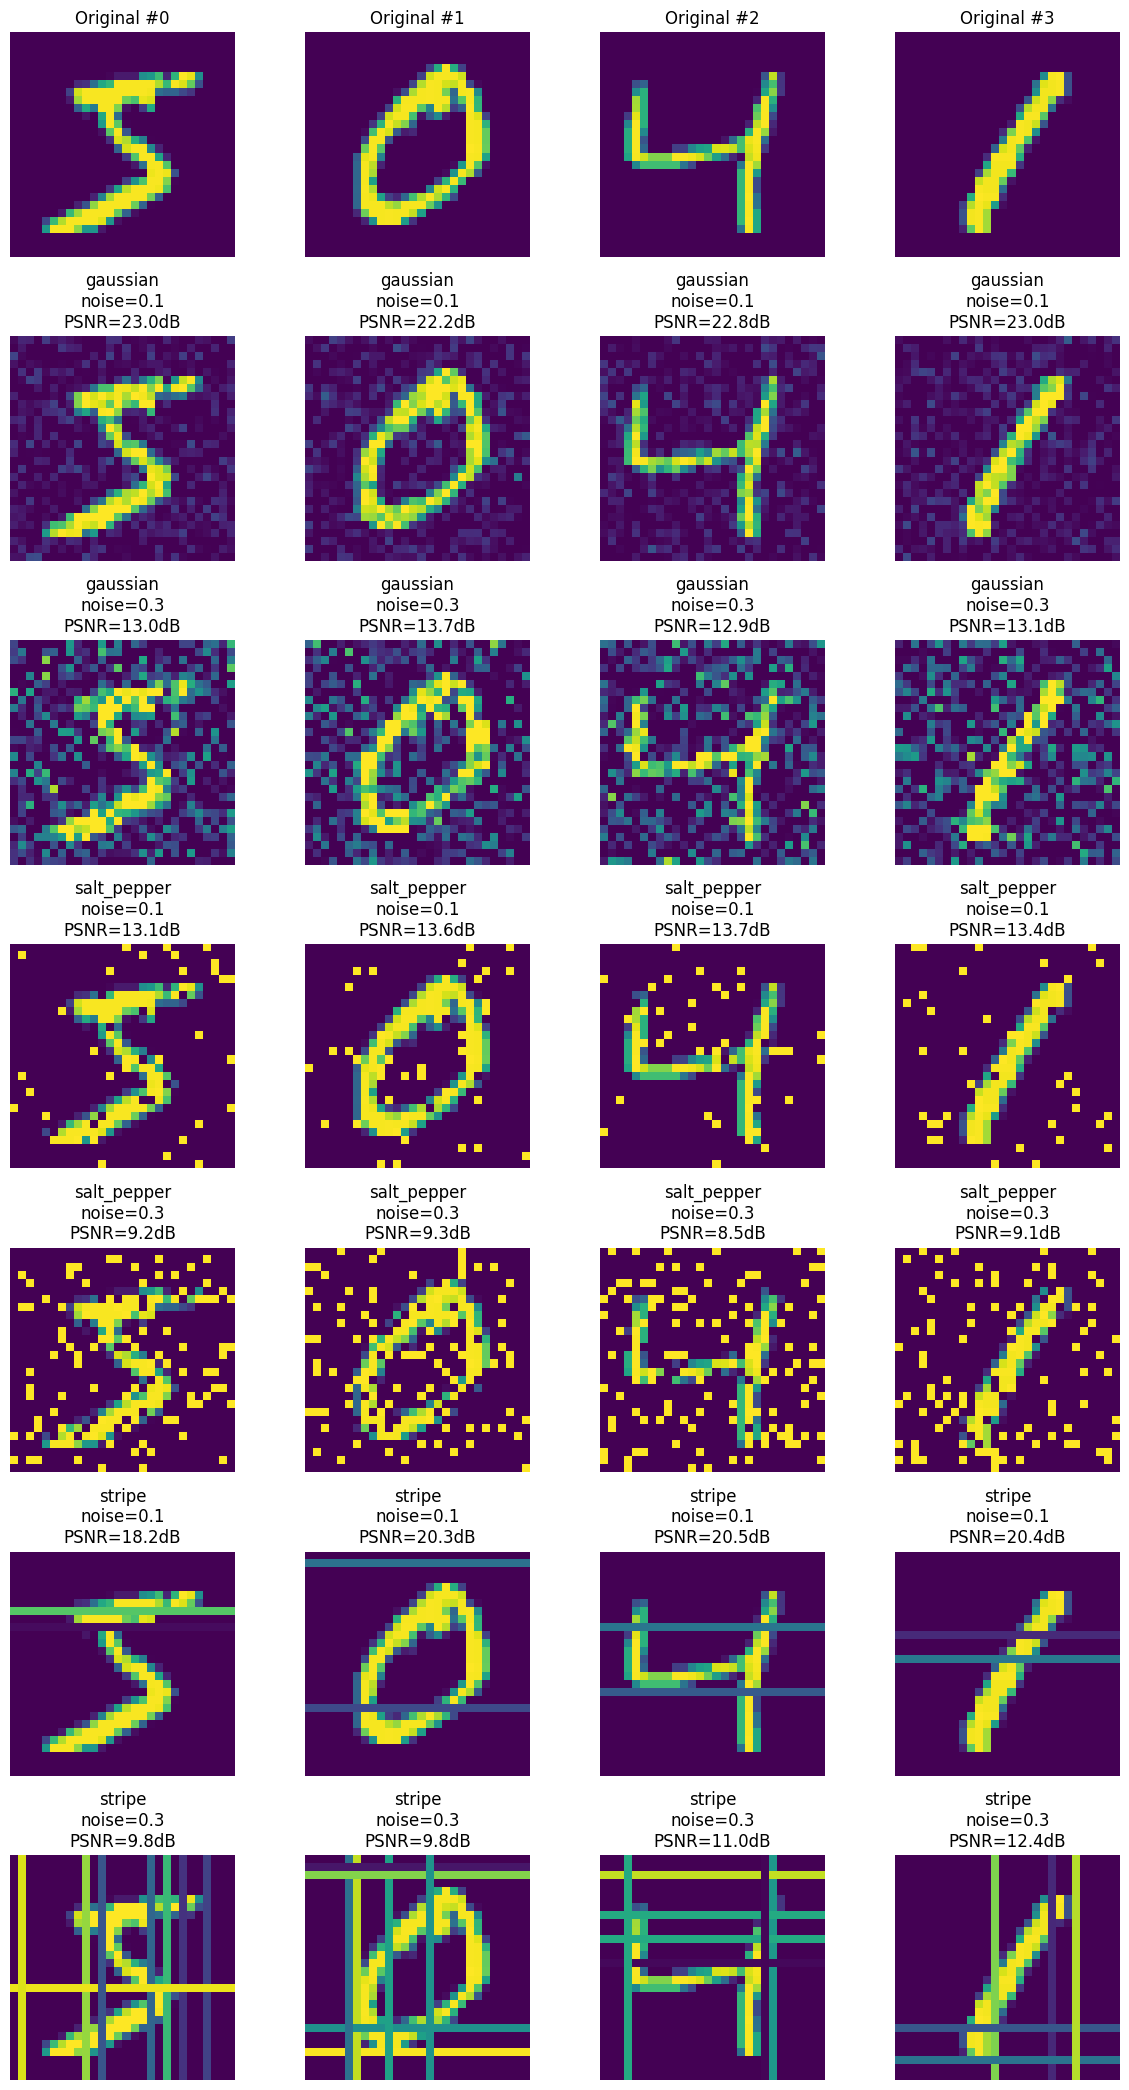

In [ ]:
visualize_noise_types()

## задание 4
    4.1 записать цикл обучения модели
    4.2 провести обучение
    4.3 оценить и визуализировать результаты

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [13]:
AE = Autoencoder_Base(hiden_size=16, im_size=[1, 28, 28], depth=3)
AE = AE.to(device)

In [14]:
loss_fn = nn.MSELoss()

In [15]:
# optimizer = torch.optim.Adam([
#     {'params': AE.decoder.parameters(), 'lr': 1e-4},
#     {'params': AE.encoder.parameters(), 'lr': 1e-5},
# ])
optimizer = torch.optim.Adam(AE.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.2)

In [16]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for batch_idx, (noisy_images, clean_images) in enumerate(dataloader):
        noisy_images = noisy_images.to(device)
        clean_images = clean_images.to(device)

        optimizer.zero_grad()
        outputs = model(noisy_images)
        loss = loss_fn(outputs, clean_images)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f".", end="")
    print()
    return total_loss / len(dataloader)

def validate_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    total_psnr = 0

    with torch.no_grad():
        for noisy_images, clean_images in dataloader:
            noisy_images = noisy_images.to(device)
            clean_images = clean_images.to(device)

            outputs = model(noisy_images)
            loss = loss_fn(outputs, clean_images)
            total_loss += loss.item()

            psnr = psnr_compute(
                clean_images,
                outputs,
                torch.tensor(outputs.shape[0], dtype=torch.float32),
                torch.tensor(1.0),
                image_size=28
            )
            total_psnr += psnr.item()

    return total_loss / len(dataloader), total_psnr / len(dataloader)

In [18]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, scheduler,
                epochs, device, save_path='best_model.pth'):
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    val_psnrs = []

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')

        train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device)
        train_losses.append(train_loss)

        val_loss, val_psnr = validate_epoch(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)
        val_psnrs.append(val_psnr)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': val_loss,
                'psnr': val_psnr,
            }, save_path)
            print(f'Best model saved with val_loss: {val_loss:.4f}')

        print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PSNR: {val_psnr:.2f} dB')
        print(f'Current lr: {optimizer.param_groups[0]["lr"]:.2e}')
        print()

    return train_losses, val_losses, val_psnrs, model

Обучаем автокодировщик

In [19]:
train_losses, val_losses, val_psnrs, AE_train = train_model(
    model=AE,
    train_loader=train_loader_gauss,
    val_loader=valid_loader_gauss,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=10,
    device=device,
    save_path='best_denoising_model.pth'
)

Epoch 1/10
..........
Best model saved with val_loss: 0.0256
Train Loss: 0.0558 | Val Loss: 0.0256 | Val PSNR: 15.93 dB
Current lr: 1.00e-03

Epoch 2/10
..........
Best model saved with val_loss: 0.0101
Train Loss: 0.0151 | Val Loss: 0.0101 | Val PSNR: 19.99 dB
Current lr: 1.00e-03

Epoch 3/10
..........
Best model saved with val_loss: 0.0080
Train Loss: 0.0086 | Val Loss: 0.0080 | Val PSNR: 20.99 dB
Current lr: 1.00e-03

Epoch 4/10
..........
Best model saved with val_loss: 0.0071
Train Loss: 0.0071 | Val Loss: 0.0071 | Val PSNR: 21.52 dB
Current lr: 1.00e-03

Epoch 5/10
..........
Best model saved with val_loss: 0.0061
Train Loss: 0.0064 | Val Loss: 0.0061 | Val PSNR: 22.20 dB
Current lr: 1.00e-03

Epoch 6/10
..........
Best model saved with val_loss: 0.0058
Train Loss: 0.0059 | Val Loss: 0.0058 | Val PSNR: 22.40 dB
Current lr: 1.00e-03

Epoch 7/10
..........
Best model saved with val_loss: 0.0058
Train Loss: 0.0057 | Val Loss: 0.0058 | Val PSNR: 22.41 dB
Current lr: 1.00e-03

Epoch 

In [25]:
def visualize_denoising_samples(model, dataset, device, num_samples=4, title=None):
    model.eval()

    fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 2.5))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for n in range(num_samples):
        im_noisy, im_clean = dataset[n]

        with torch.no_grad():
            im_denoised = model(im_noisy.to(device)[None])

        psnr_input = psnr_compute(
            im_clean.unsqueeze(0),
            im_noisy.unsqueeze(0),
            torch.tensor(1.0),
            torch.tensor(1.0),
            image_size=28
        )

        psnr_output = psnr_compute(
            im_clean.unsqueeze(0),
            im_denoised.cpu(),
            torch.tensor(1.0),
            torch.tensor(1.0),
            image_size=28
        )

        axes[n, 0].imshow(im_noisy[0, :, :])
        axes[n, 0].set_title(f'Noisy Input\nPSNR={psnr_input.item():.1f}dB')
        axes[n, 0].axis('off')

        axes[n, 1].imshow(im_clean[0, :, :])
        axes[n, 1].set_title('Ground Truth')
        axes[n, 1].axis('off')

        axes[n, 2].imshow(im_denoised.detach().cpu().numpy()[0, 0, :, :])
        axes[n, 2].set_title(f'Denoised Output\nPSNR={psnr_output.item():.1f}dB')
        axes[n, 2].axis('off')

    if title:
        plt.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

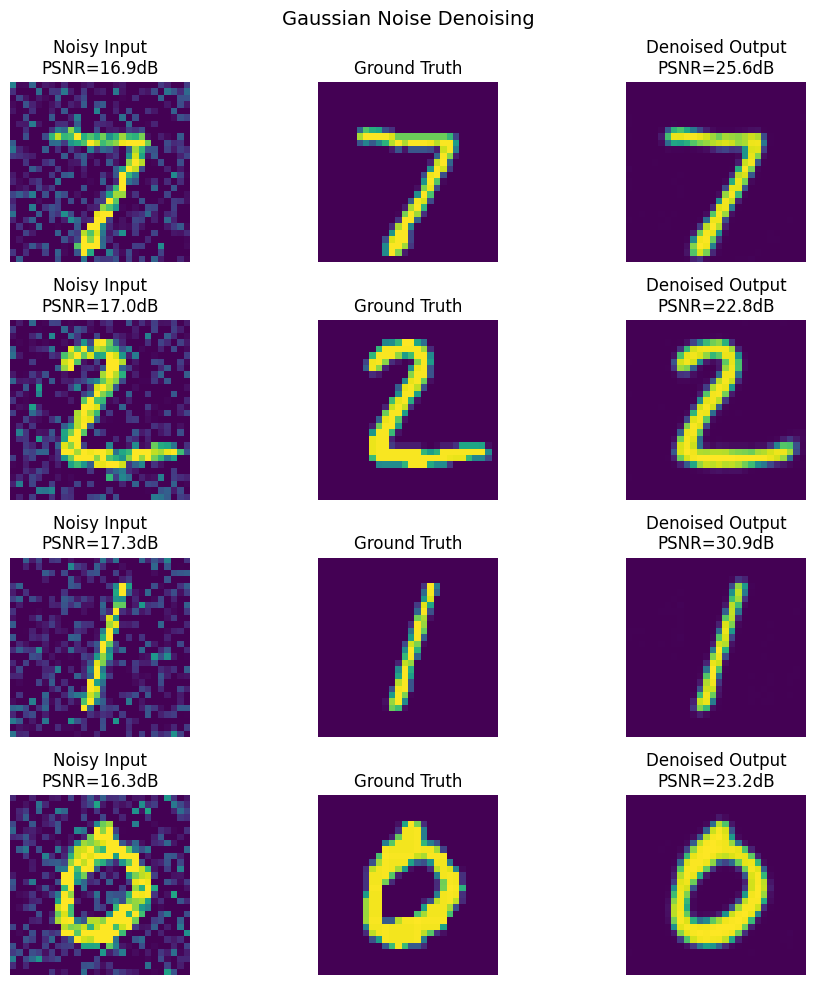

In [26]:
visualize_denoising_samples(
    model=AE,
    dataset=valid_dataset_gauss,
    device=device,
    num_samples=4,
    title='Gaussian Noise Denoising'
)

In [21]:
def evaluate_denoising_quality(model, dataset, device, num_samples=100):
    model.eval()
    psnr_before = []
    psnr_after = []

    num_samples = min(num_samples, len(dataset))

    with torch.no_grad():
        for i in range(num_samples):
            im_noisy, im_clean = dataset[i]
            y = model(im_noisy.to(device)[None])

            psnr_in = psnr_compute(
                im_clean.unsqueeze(0),
                im_noisy.unsqueeze(0),
                torch.tensor(1.0),
                torch.tensor(1.0),
                image_size=28
            )
            psnr_out = psnr_compute(
                im_clean.unsqueeze(0),
                y.cpu(),
                torch.tensor(1.0),
                torch.tensor(1.0),
                image_size=28
            )

            psnr_before.append(psnr_in.item())
            psnr_after.append(psnr_out.item())

    mean_before = np.mean(psnr_before)
    std_before = np.std(psnr_before)
    mean_after = np.mean(psnr_after)
    std_after = np.std(psnr_after)
    improvement = mean_after - mean_before

    print(f"PSNR до шумоподавления: {mean_before:.2f} ± {std_before:.2f} dB")
    print(f"PSNR после шумоподавления: {mean_after:.2f} ± {std_after:.2f} dB")
    print(f"Улучшение: {improvement:.2f} dB")

    plt.figure(figsize=(10, 5))
    plt.hist(psnr_before, alpha=0.5, bins=20, label='Before denoising')
    plt.hist(psnr_after, alpha=0.5, bins=20, label='After denoising')
    plt.xlabel('PSNR (dB)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

    return psnr_before, psnr_after

PSNR до шумоподавления: 16.79 ± 0.31 dB
PSNR после шумоподавления: 23.71 ± 2.26 dB
Улучшение: 6.93 dB


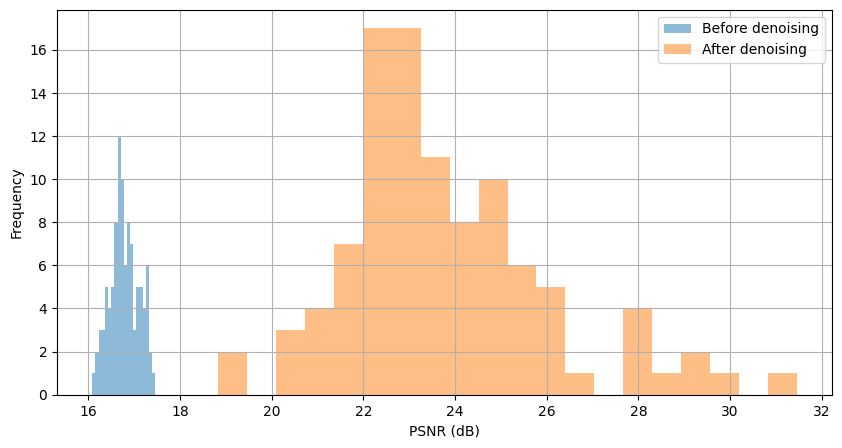

In [22]:
psnr_before, psnr_after = evaluate_denoising_quality(
    model=AE,
    dataset=valid_dataset_gauss,
    device=device,
    num_samples=100
)

## задание 5
    5.1 провести обучение моделей для разных значений noise: 0.1, 0.2, 0.5, 0.8
    5.2 оценить и визуализировать результаты
    5.3 Загрузить набор данных fashionMNIST (test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform))
    5.4 Провести подготовку данных с зашумлением (гаусов шум 0.1) и проверить качество очистки данных при использовании модели обученной на очистке от гаусового шума набора MNIST-рукописные цифры

In [29]:
# 5.1
noise_levels = [0.1, 0.2, 0.5, 0.8]
trained_models = {}
training_history = {}

Noise=0.1
Epoch 1/10
..........
Best model saved with val_loss: 0.0218
Train Loss: 0.0525 | Val Loss: 0.0218 | Val PSNR: 16.62 dB
Current lr: 1.00e-03

Epoch 2/10
..........
Best model saved with val_loss: 0.0101
Train Loss: 0.0135 | Val Loss: 0.0101 | Val PSNR: 19.98 dB
Current lr: 1.00e-03

Epoch 3/10
..........
Best model saved with val_loss: 0.0078
Train Loss: 0.0083 | Val Loss: 0.0078 | Val PSNR: 21.08 dB
Current lr: 1.00e-03

Epoch 4/10
..........
Best model saved with val_loss: 0.0067
Train Loss: 0.0068 | Val Loss: 0.0067 | Val PSNR: 21.77 dB
Current lr: 1.00e-03

Epoch 5/10
..........
Best model saved with val_loss: 0.0056
Train Loss: 0.0060 | Val Loss: 0.0056 | Val PSNR: 22.57 dB
Current lr: 1.00e-03

Epoch 6/10
..........
Best model saved with val_loss: 0.0052
Train Loss: 0.0054 | Val Loss: 0.0052 | Val PSNR: 22.84 dB
Current lr: 1.00e-03

Epoch 7/10
..........
Best model saved with val_loss: 0.0047
Train Loss: 0.0051 | Val Loss: 0.0047 | Val PSNR: 23.35 dB
Current lr: 1.00e-

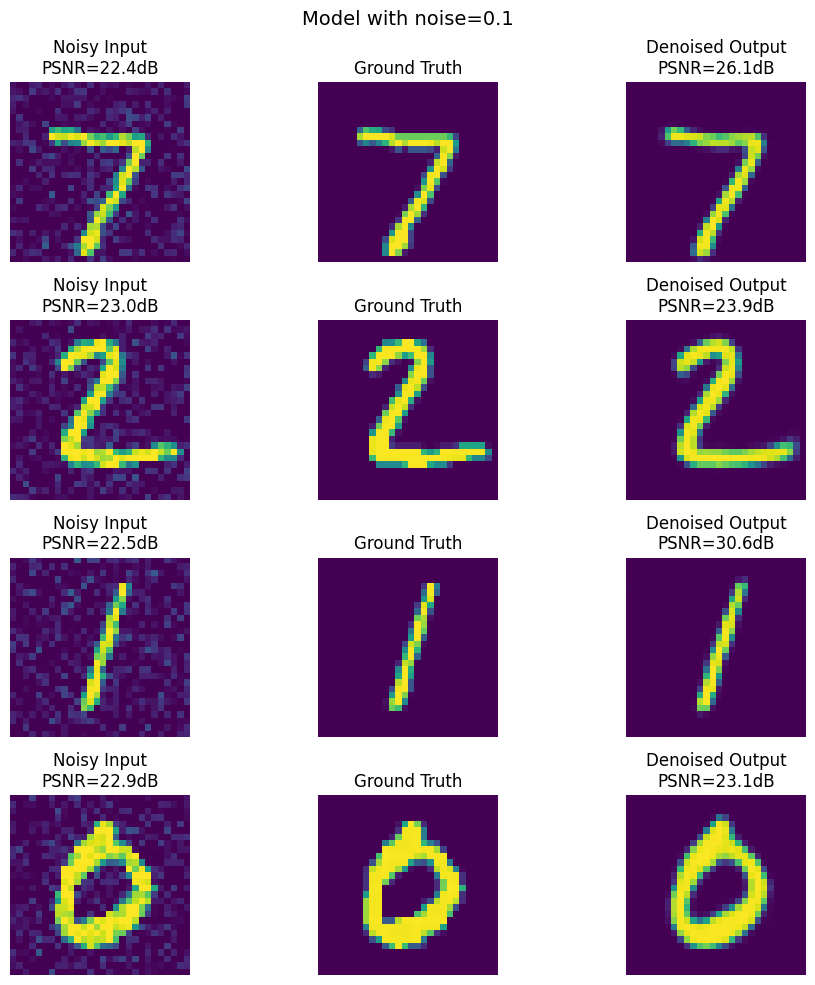

PSNR до шумоподавления: 22.76 ± 0.32 dB
PSNR после шумоподавления: 24.73 ± 2.24 dB
Улучшение: 1.97 dB


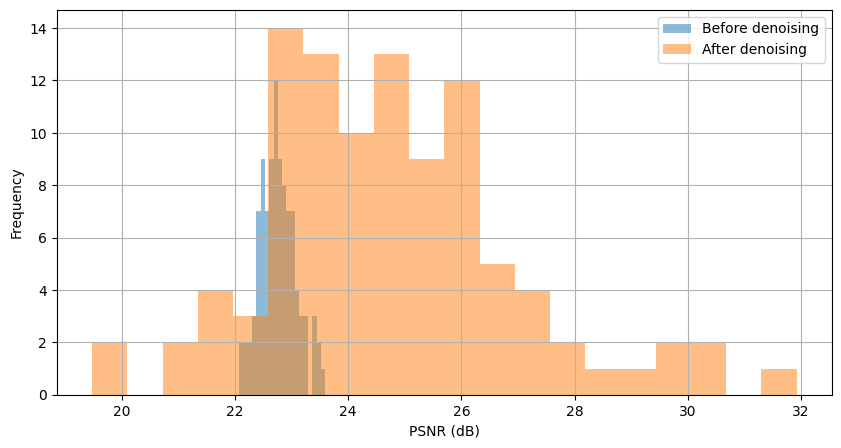

Noise=0.2
Epoch 1/10
..........
Best model saved with val_loss: 0.0246
Train Loss: 0.0529 | Val Loss: 0.0246 | Val PSNR: 16.11 dB
Current lr: 1.00e-03

Epoch 2/10
..........
Best model saved with val_loss: 0.0101
Train Loss: 0.0146 | Val Loss: 0.0101 | Val PSNR: 19.99 dB
Current lr: 1.00e-03

Epoch 3/10
..........
Best model saved with val_loss: 0.0082
Train Loss: 0.0090 | Val Loss: 0.0082 | Val PSNR: 20.90 dB
Current lr: 1.00e-03

Epoch 4/10
..........
Best model saved with val_loss: 0.0072
Train Loss: 0.0075 | Val Loss: 0.0072 | Val PSNR: 21.45 dB
Current lr: 1.00e-03

Epoch 5/10
..........
Best model saved with val_loss: 0.0065
Train Loss: 0.0068 | Val Loss: 0.0065 | Val PSNR: 21.86 dB
Current lr: 1.00e-03

Epoch 6/10
..........
Best model saved with val_loss: 0.0063
Train Loss: 0.0063 | Val Loss: 0.0063 | Val PSNR: 21.99 dB
Current lr: 1.00e-03

Epoch 7/10
..........
Best model saved with val_loss: 0.0056
Train Loss: 0.0058 | Val Loss: 0.0056 | Val PSNR: 22.52 dB
Current lr: 1.00e-

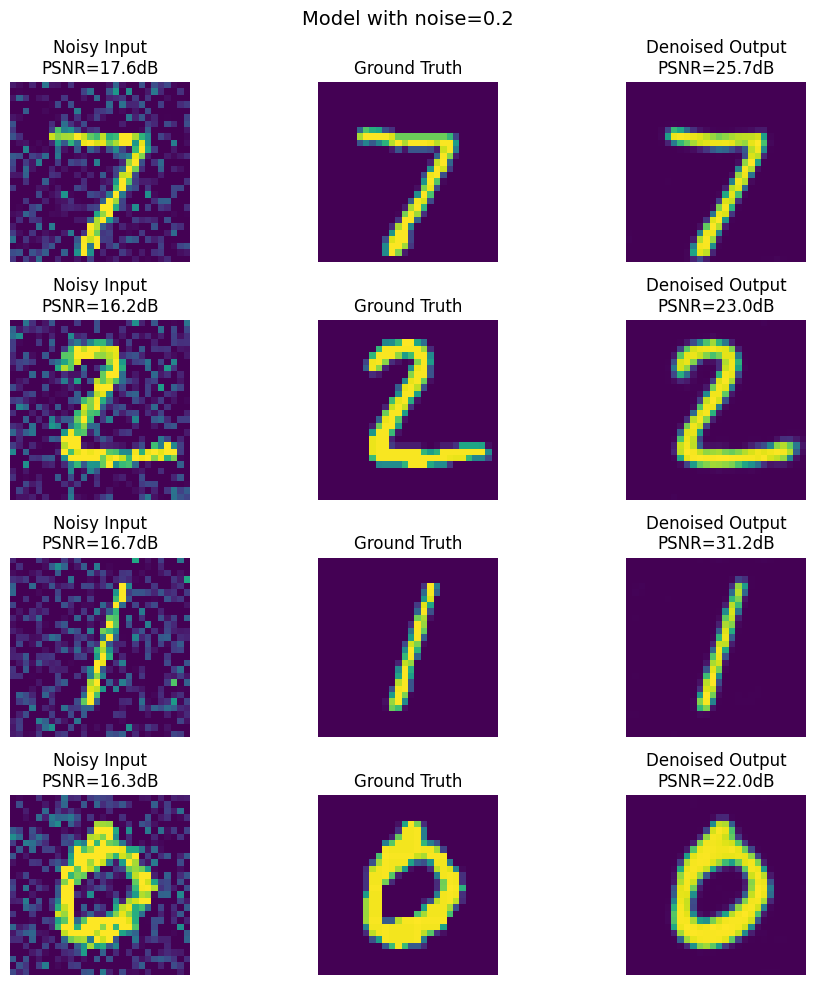

PSNR до шумоподавления: 16.80 ± 0.37 dB
PSNR после шумоподавления: 23.57 ± 1.99 dB
Улучшение: 6.77 dB


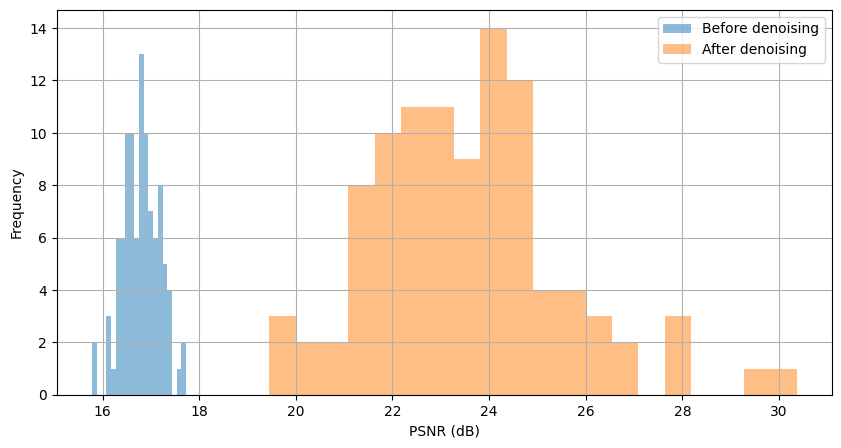

Noise=0.5
Epoch 1/10
..........
Best model saved with val_loss: 0.0295
Train Loss: 0.0552 | Val Loss: 0.0295 | Val PSNR: 15.32 dB
Current lr: 1.00e-03

Epoch 2/10
..........
Best model saved with val_loss: 0.0152
Train Loss: 0.0198 | Val Loss: 0.0152 | Val PSNR: 18.19 dB
Current lr: 1.00e-03

Epoch 3/10
..........
Best model saved with val_loss: 0.0135
Train Loss: 0.0144 | Val Loss: 0.0135 | Val PSNR: 18.71 dB
Current lr: 1.00e-03

Epoch 4/10
..........
Best model saved with val_loss: 0.0126
Train Loss: 0.0130 | Val Loss: 0.0126 | Val PSNR: 19.01 dB
Current lr: 1.00e-03

Epoch 5/10
..........
Best model saved with val_loss: 0.0119
Train Loss: 0.0123 | Val Loss: 0.0119 | Val PSNR: 19.25 dB
Current lr: 1.00e-03

Epoch 6/10
..........
Best model saved with val_loss: 0.0114
Train Loss: 0.0119 | Val Loss: 0.0114 | Val PSNR: 19.42 dB
Current lr: 1.00e-03

Epoch 7/10
..........
Best model saved with val_loss: 0.0111
Train Loss: 0.0115 | Val Loss: 0.0111 | Val PSNR: 19.57 dB
Current lr: 1.00e-

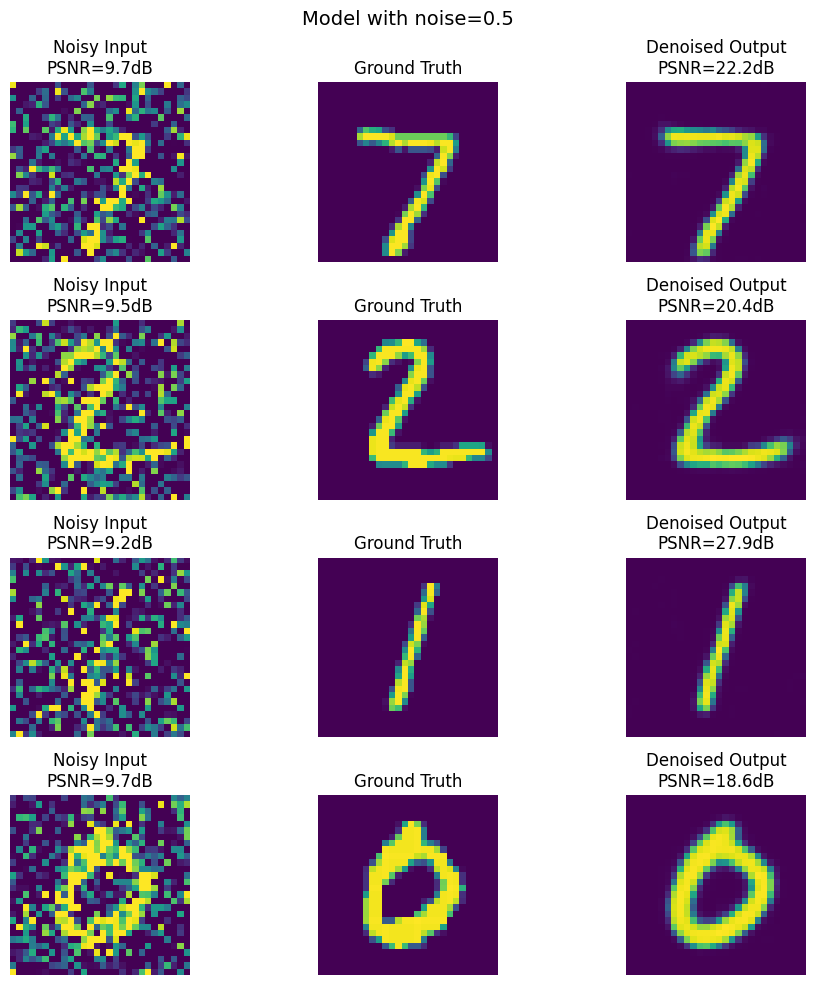

PSNR до шумоподавления: 9.37 ± 0.25 dB
PSNR после шумоподавления: 20.27 ± 2.17 dB
Улучшение: 10.90 dB


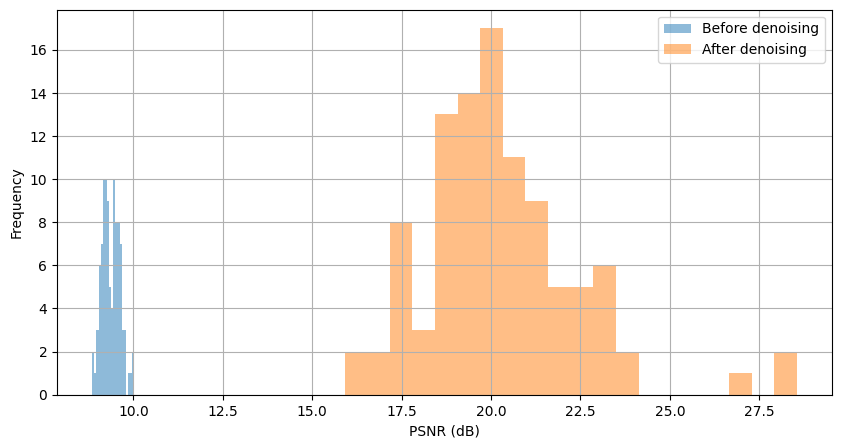

Noise=0.8
Epoch 1/10
..........
Best model saved with val_loss: 0.0360
Train Loss: 0.0599 | Val Loss: 0.0360 | Val PSNR: 14.45 dB
Current lr: 1.00e-03

Epoch 2/10
..........
Best model saved with val_loss: 0.0244
Train Loss: 0.0284 | Val Loss: 0.0244 | Val PSNR: 16.12 dB
Current lr: 1.00e-03

Epoch 3/10
..........
Best model saved with val_loss: 0.0222
Train Loss: 0.0236 | Val Loss: 0.0222 | Val PSNR: 16.54 dB
Current lr: 1.00e-03

Epoch 4/10
..........
Best model saved with val_loss: 0.0215
Train Loss: 0.0222 | Val Loss: 0.0215 | Val PSNR: 16.68 dB
Current lr: 1.00e-03

Epoch 5/10
..........
Best model saved with val_loss: 0.0209
Train Loss: 0.0214 | Val Loss: 0.0209 | Val PSNR: 16.81 dB
Current lr: 1.00e-03

Epoch 6/10
..........
Best model saved with val_loss: 0.0205
Train Loss: 0.0208 | Val Loss: 0.0205 | Val PSNR: 16.90 dB
Current lr: 1.00e-03

Epoch 7/10
..........
Best model saved with val_loss: 0.0202
Train Loss: 0.0205 | Val Loss: 0.0202 | Val PSNR: 16.96 dB
Current lr: 1.00e-

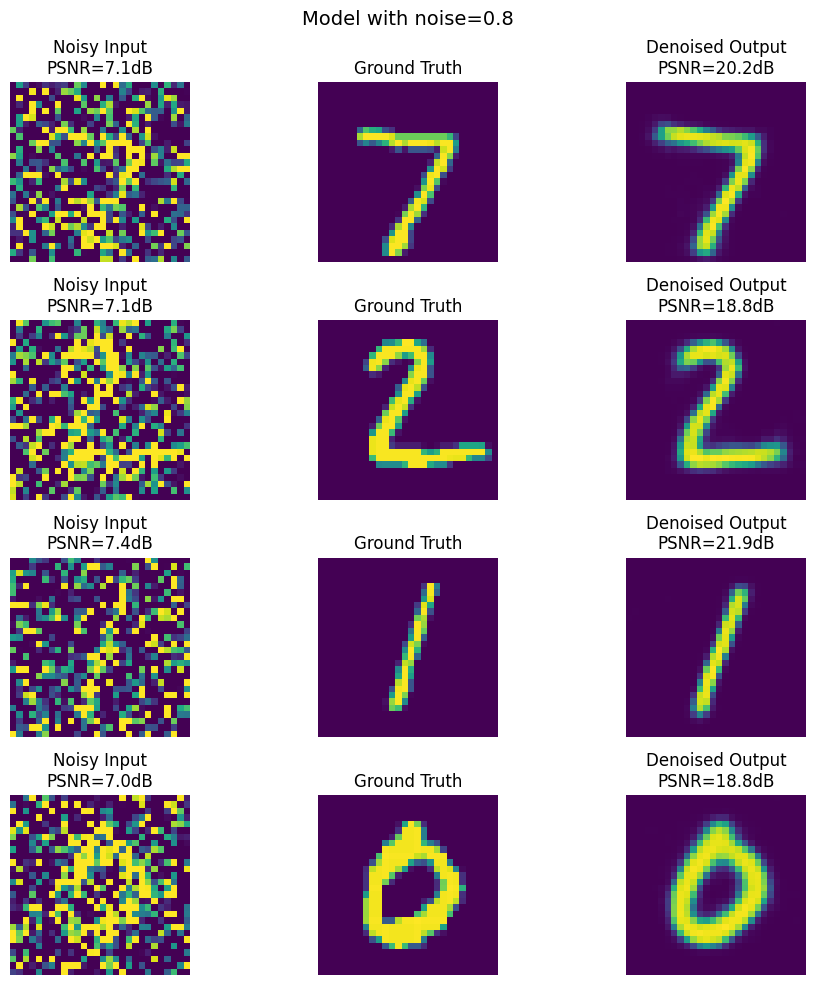

PSNR до шумоподавления: 6.81 ± 0.25 dB
PSNR после шумоподавления: 17.55 ± 2.23 dB
Улучшение: 10.74 dB


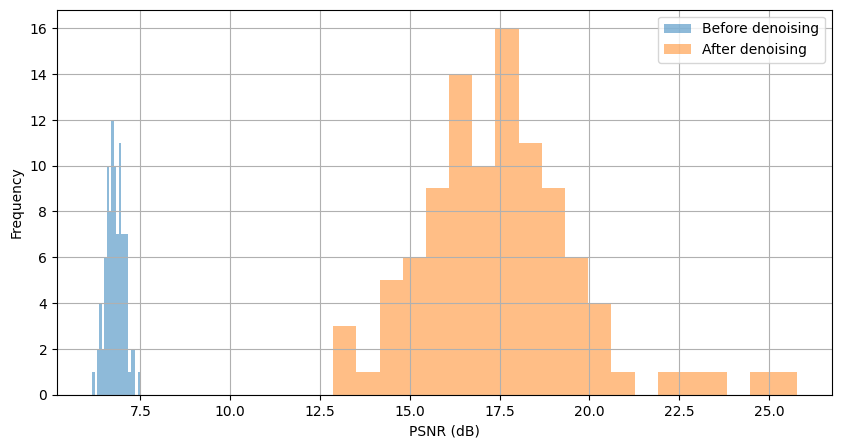

In [30]:
for noise_level in noise_levels:
    print(f"Noise={noise_level}")

    train_dataset = NoiseDataset(ds, noise=noise_level, noise_type='gaussian')
    valid_dataset = NoiseDataset(ds_test, noise=noise_level, noise_type='gaussian')

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True
    )

    model = Autoencoder_Base(hiden_size=16, im_size=[1, 28, 28], depth=3)
    model = model.to(device)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.2
    )

    train_losses, val_losses, val_psnrs, trained_model = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=10,
        device=device,
        save_path=f'best_model_noise_{noise_level}.pth'
    )

    trained_models[noise_level] = trained_model
    training_history[noise_level] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_psnrs': val_psnrs
    }

    visualize_denoising_samples(
        model=model,
        dataset=valid_dataset,
        device=device,
        num_samples=4,
        title=f'Model with noise={noise_level}'
    )

    psnr_before, psnr_after = evaluate_denoising_quality(
        model=model,
        dataset=valid_dataset,
        device=device,
        num_samples=100
    )

In [31]:
def plot_training_comparison(training_history):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = plt.cm.rainbow(np.linspace(0, 1, len(training_history)))

    ax = axes[0]
    for (noise_level, data), color in zip(training_history.items(), colors):
        epochs = range(1, len(data['val_losses']) + 1)
        ax.plot(epochs, data['val_losses'], label=f'noise={noise_level}', color=color,
               linewidth=2.5, marker='o', markersize=7)

    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Validation Loss', fontsize=16)
    ax.set_title('Validation Loss Comparison', fontsize=18)
    ax.legend(loc='best', fontsize=14)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for (noise_level, data), color in zip(training_history.items(), colors):
        epochs = range(1, len(data['val_psnrs']) + 1)
        ax.plot(epochs, data['val_psnrs'], label=f'noise={noise_level}', color=color,
               linewidth=2.5, marker='s', markersize=7)

    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('PSNR (dB)', fontsize=16)
    ax.set_title('Validation PSNR Comparison', fontsize=18)
    ax.legend(loc='best', fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

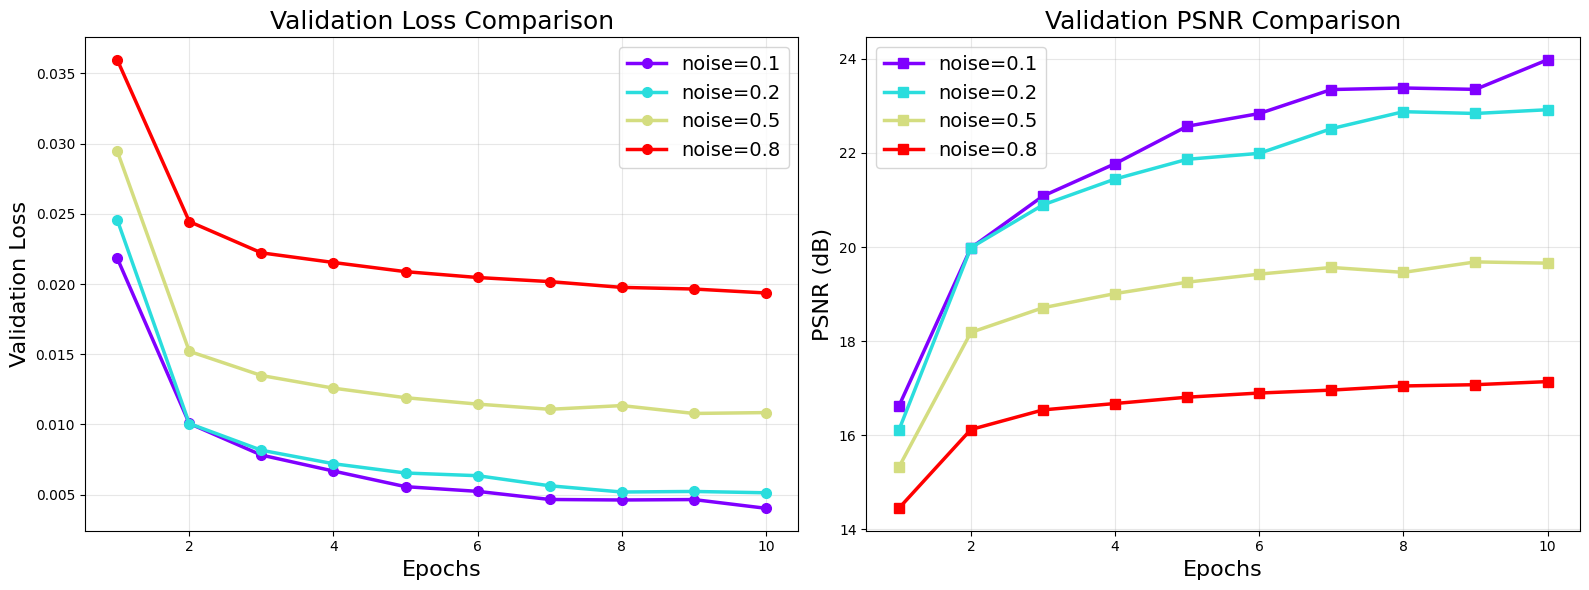

In [32]:
plot_training_comparison(training_history)

In [33]:
def visualize_model_on_all_noises(model, train_noise, noise_levels, device, sample_idx=0):
    model.eval()

    num_test_noises = len(noise_levels)
    fig, axes = plt.subplots(num_test_noises, 3, figsize=(10, num_test_noises * 2.5))

    if num_test_noises == 1:
        axes = axes.reshape(1, -1)

    for test_idx, test_noise in enumerate(noise_levels):
        test_dataset = NoiseDataset(ds_test, noise=test_noise, noise_type='gaussian')
        im_noisy, im_clean = test_dataset[sample_idx]

        with torch.no_grad():
            im_denoised = model(im_noisy.to(device)[None])

        psnr_input = psnr_compute(
            im_clean.unsqueeze(0),
            im_noisy.unsqueeze(0),
            torch.tensor(1.0),
            torch.tensor(1.0),
            image_size=28
        )

        psnr_output = psnr_compute(
            im_clean.unsqueeze(0),
            im_denoised.cpu(),
            torch.tensor(1.0),
            torch.tensor(1.0),
            image_size=28
        )

        axes[test_idx, 0].imshow(im_noisy[0, :, :])
        axes[test_idx, 0].set_title(f'Noisy Input\nPSNR={psnr_input.item():.1f}dB')
        axes[test_idx, 0].axis('off')

        axes[test_idx, 1].imshow(im_clean[0, :, :])
        axes[test_idx, 1].set_title('Ground Truth')
        axes[test_idx, 1].axis('off')

        axes[test_idx, 2].imshow(im_denoised.detach().cpu().numpy()[0, 0, :, :])
        axes[test_idx, 2].set_title(f'Denoised Output\nPSNR={psnr_output.item():.1f}dB')
        axes[test_idx, 2].axis('off')

        axes[test_idx, 0].text(
            -0.15, 0.5, f'Test noise={test_noise}',
            transform=axes[test_idx, 0].transAxes,
            ha='right', va='center', fontsize=11, fontweight='bold'
        )

    plt.suptitle(f'Model trained with noise={train_noise}', fontsize=14)
    plt.tight_layout()
    plt.show()

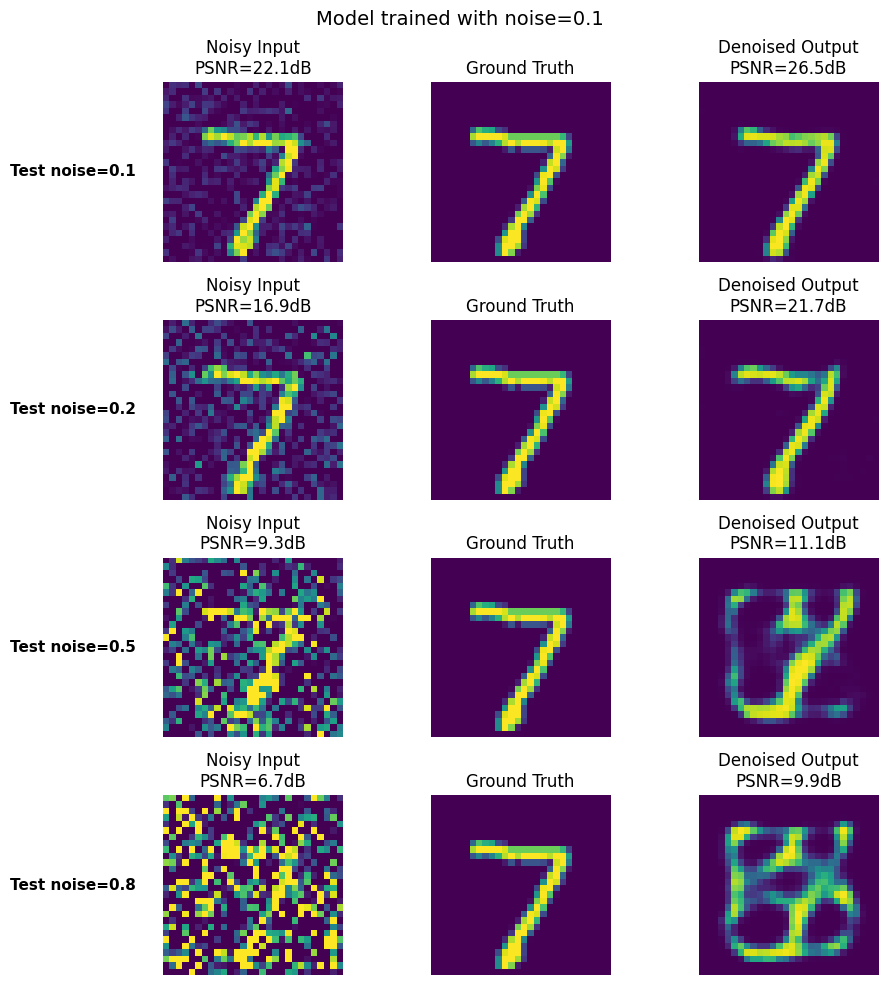

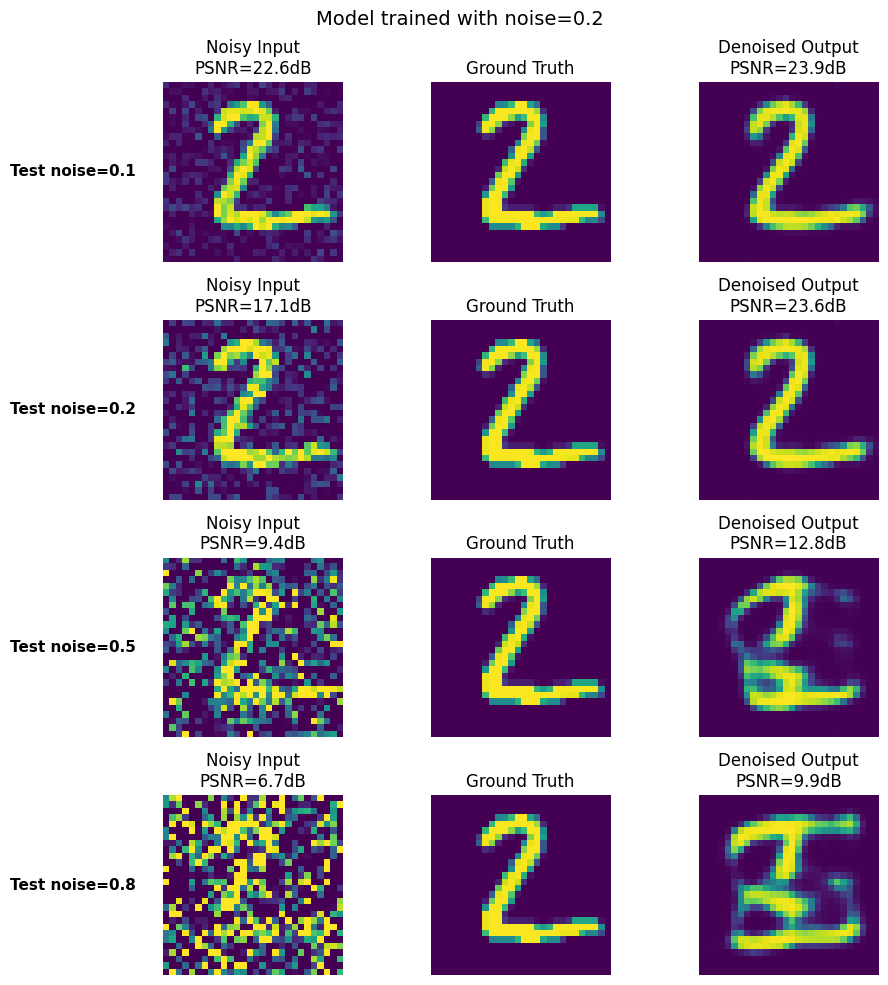

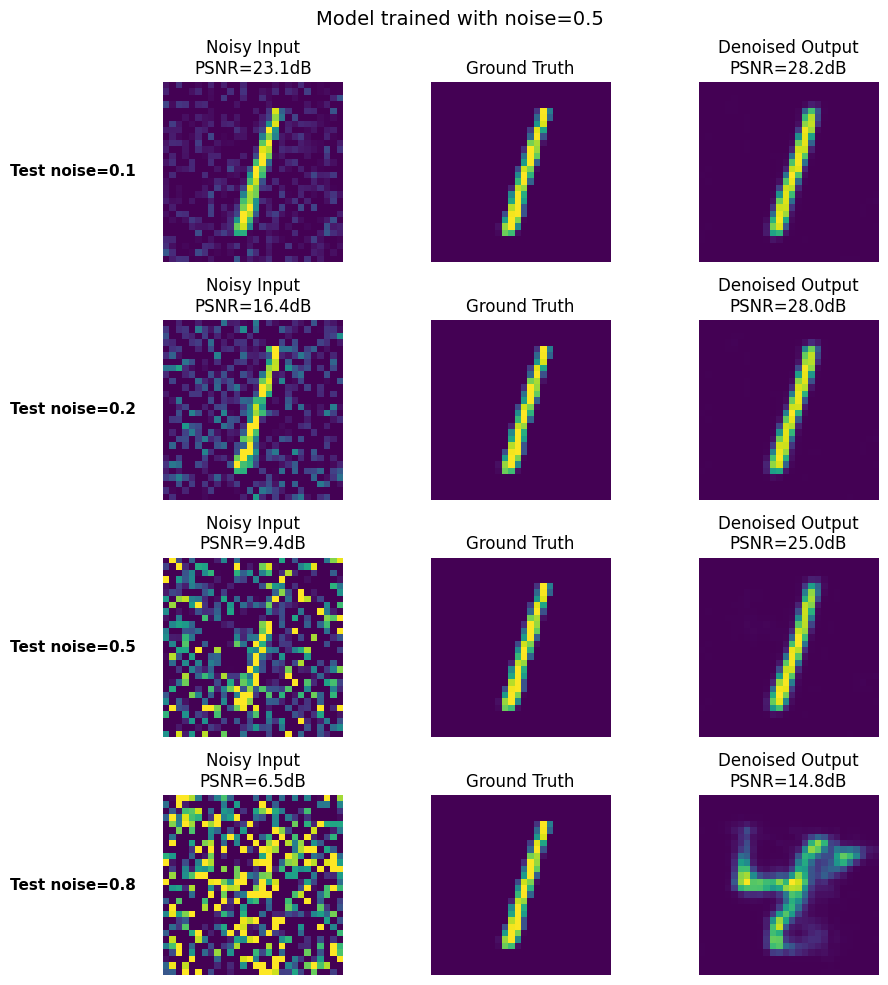

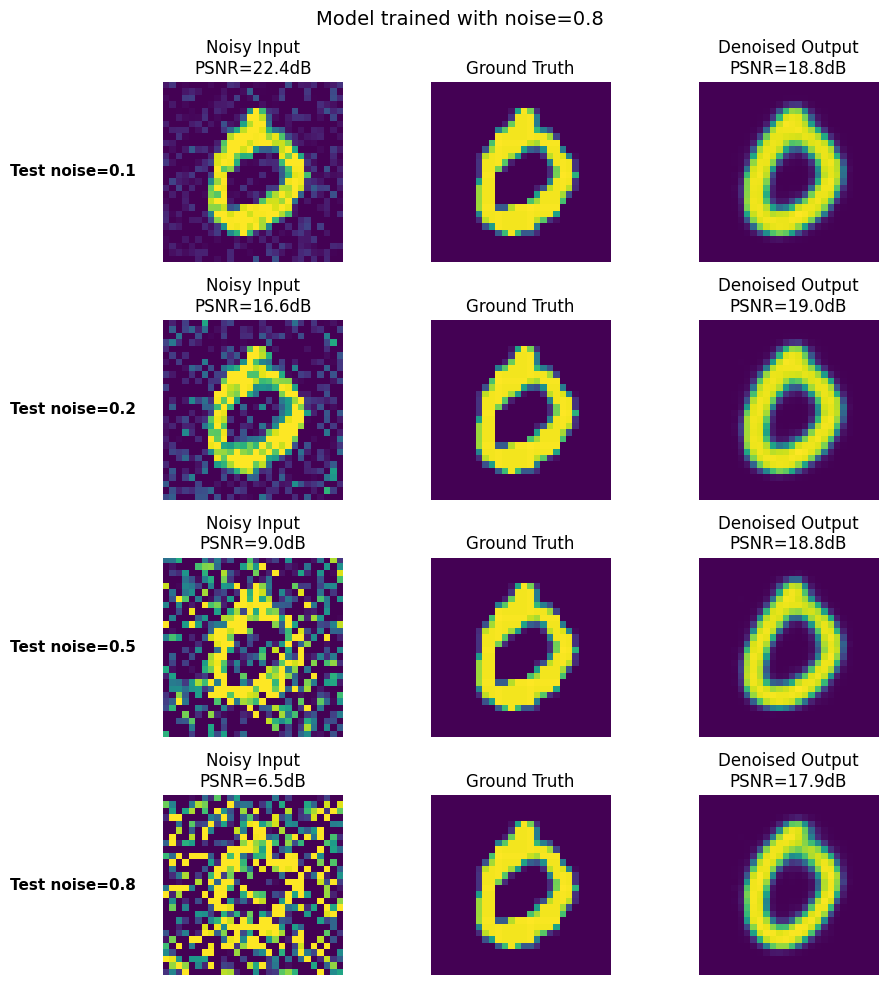

In [35]:
sample_idx = 0
for train_noise, model in trained_models.items():
    visualize_model_on_all_noises(
        model=model,
        train_noise=train_noise,
        noise_levels=noise_levels,
        device=device,
        sample_idx=sample_idx
    )
    sample_idx += 1

In [43]:
# 5.3
transform = transforms.Compose([transforms.ToTensor()])

fashion_train = datasets.FashionMNIST(root='./data', train=True, download=True)
fashion_test = datasets.FashionMNIST(root='./data', train=False, download=True)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [44]:
fashion_noisy_dataset = NoiseDataset(fashion_test, noise=0.1, noise_type='gaussian')
model_mnist = trained_models[0.1]

PSNR до шумоподавления: 21.72 ± 0.60 dB
PSNR после шумоподавления: 12.95 ± 2.34 dB
Улучшение: -8.77 dB


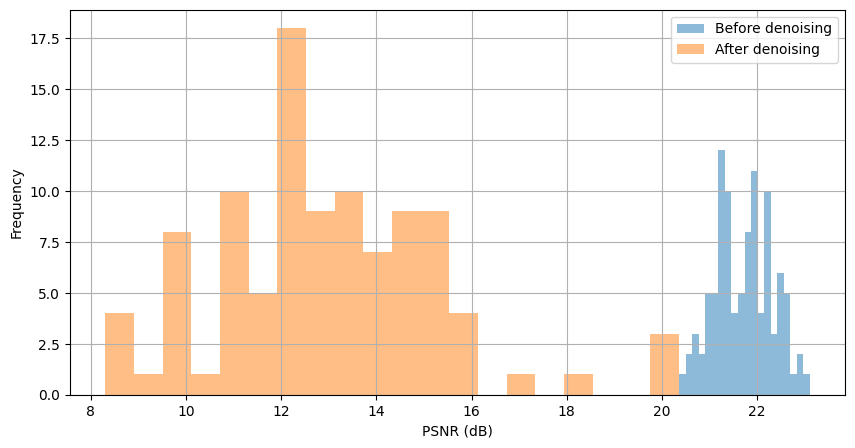

In [45]:
psnr_before, psnr_after = evaluate_denoising_quality(
    model=model_mnist,
    dataset=fashion_noisy_dataset,
    device=device,
    num_samples=100
)

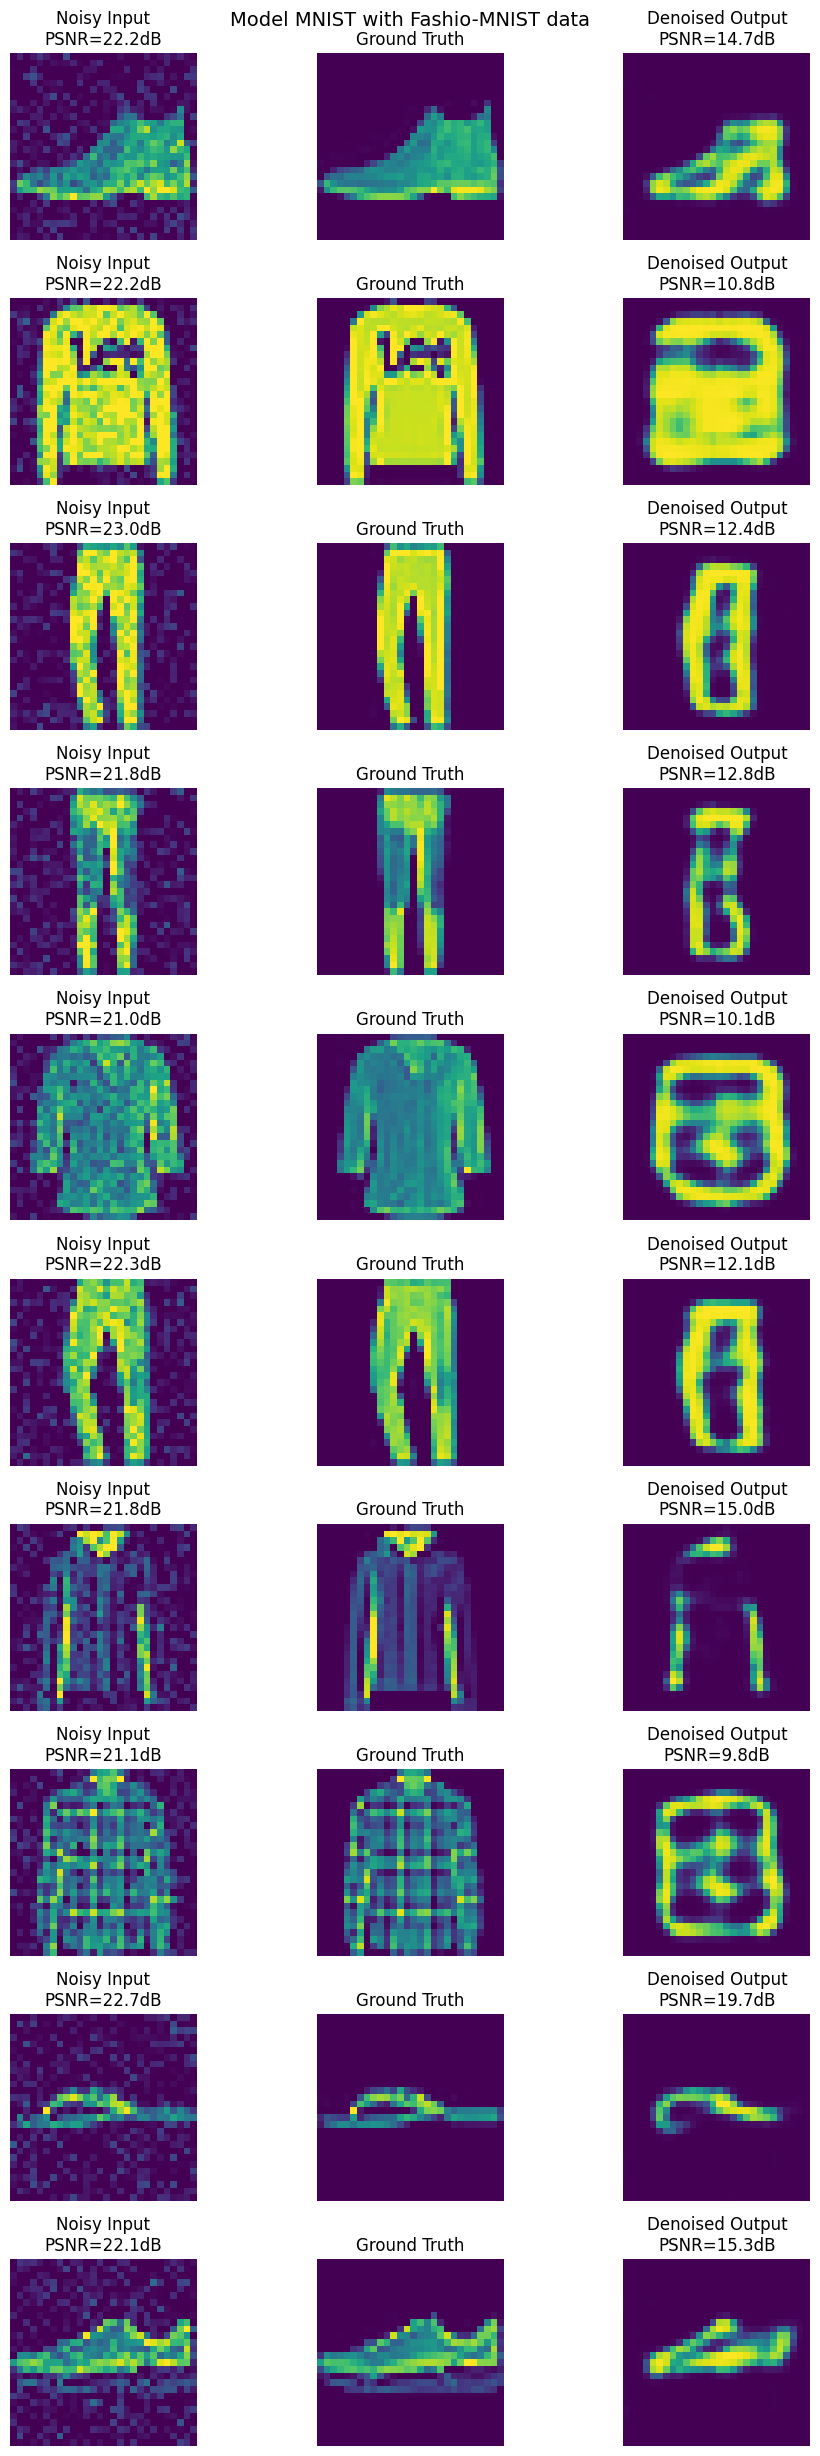

In [47]:
visualize_denoising_samples(
    model=model_mnist,
    dataset=fashion_noisy_dataset,
    device=device,
    num_samples=10,
    title=f'Model MNIST with Fashio-MNIST data'
)

### Выводы

Здесь демонстрируется классическая проблема Vanilla автокодировщика и всех Vanilla генеративных моделей - модель обучилась на одном наборе данных, но на инференс приходит другой набор данных, но модель не может придумать ничего нового, что выходит за рамки распределения объектов. Поэтому модель будет пытаться упростить изображение до цифр, убирая при этом важные детали одежды.